In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Display every column
pd.options.display.max_rows = None
pd.set_option('display.max_columns', None)

In [10]:
df = pd.read_csv('data_export_feature_engineered_6.csv')

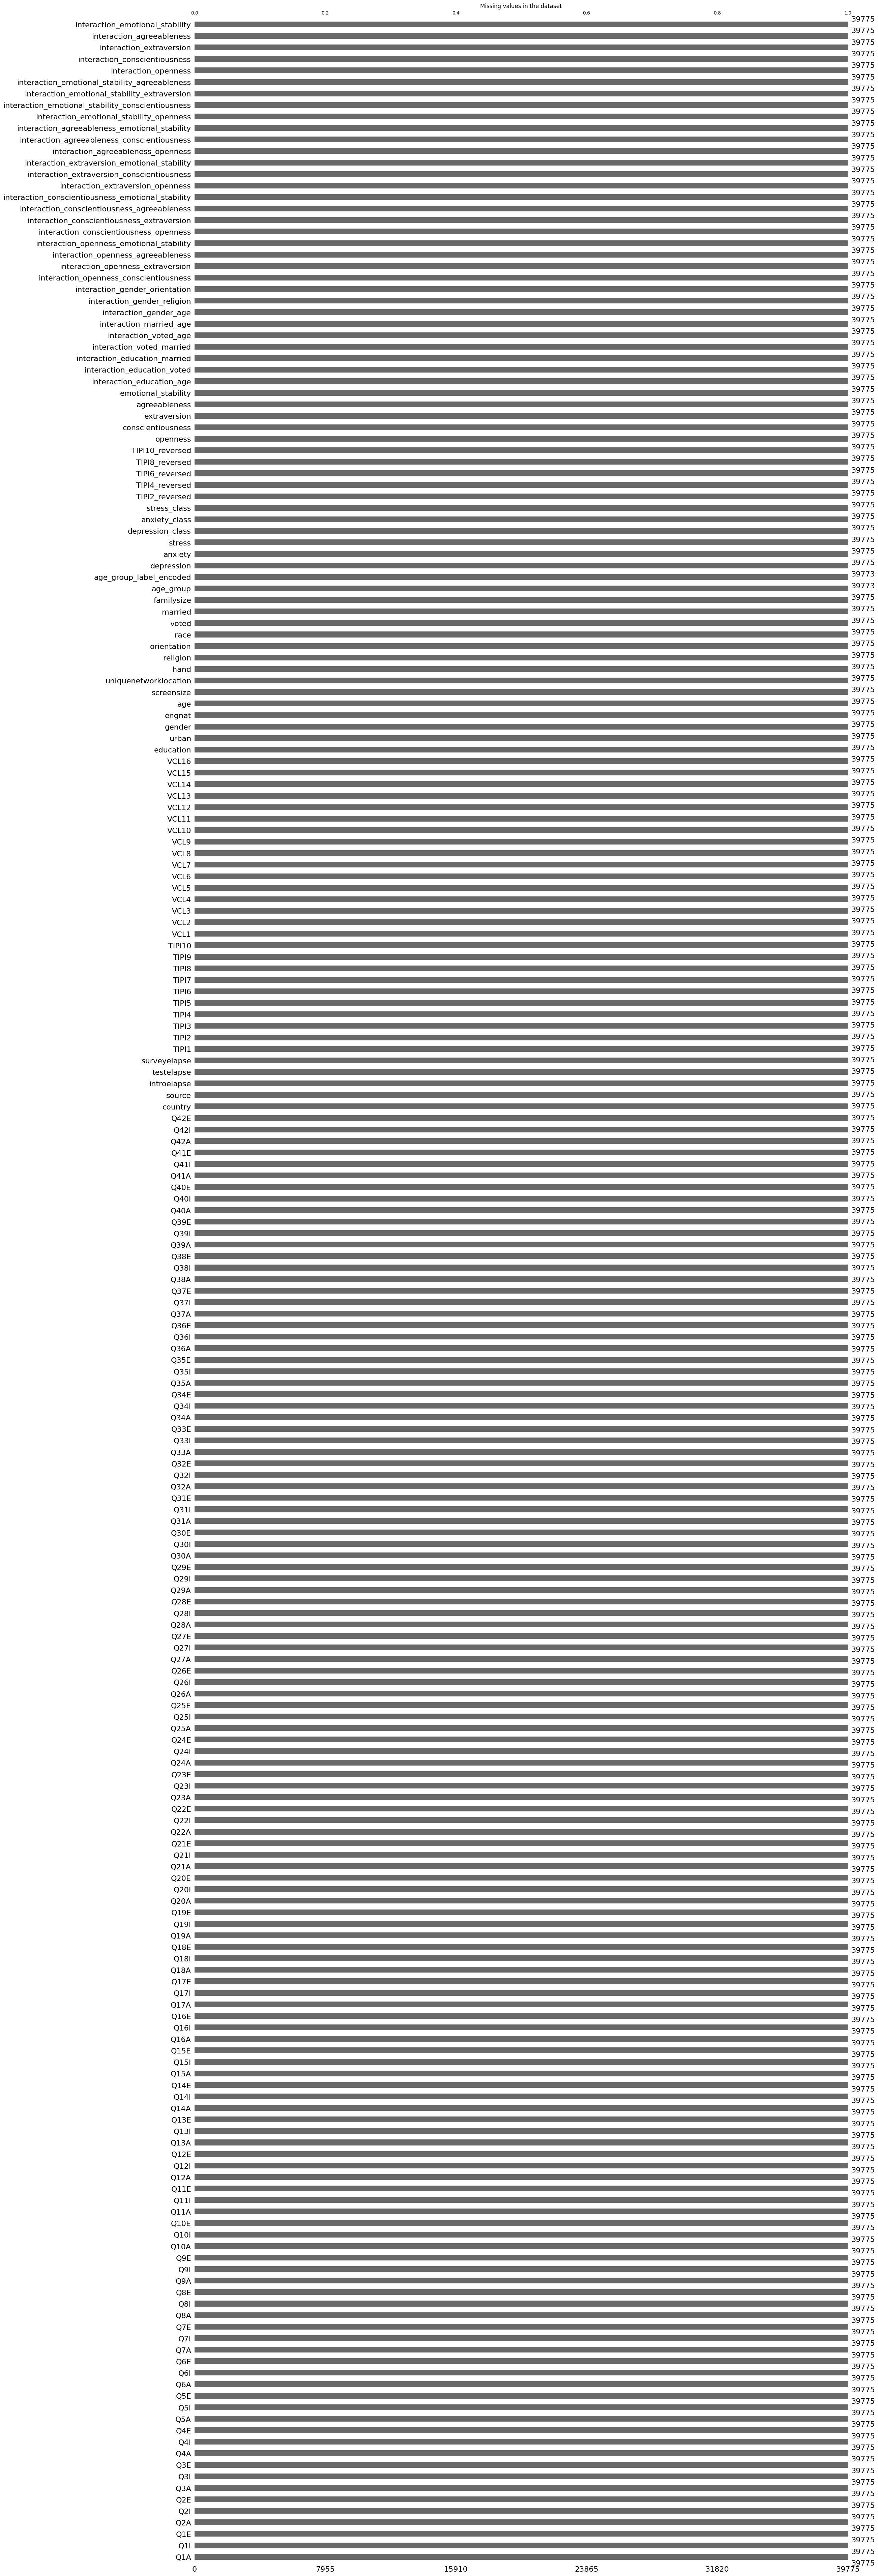

In [11]:
msno.bar(df)

plt.title('Missing values in the dataset')
plt.show()

# TODO: feature engineered familysize has missing data. 

In [12]:
# Demographic Dictionary
demo_dict = {
    'education':	    'How much education have you completed?',
    'urban':			'What type of area did you live when you were a child?',
    'gender':			'What is your gender?', 
    'engnat':			'Is English your native language?',
    'age':				'How many years old are you?',
    'hand':				'What hand do you use to write with?',
    'religion':			'What is your religion?',
    'orientation':		'What is your sexual orientation?',
    'race':				'What is your race?',
    'voted':			'Have you voted in a national election in the past year?',
    'married':			'What is your marital status?',
    'familysize':		'Including you, how many children did your mother have?'
}

# Ten Item Personality Inventory (TIPI) Dictionary
tipi_dict = {
    'TIPI1':	'Extraverted, enthusiastic',
    'TIPI2':	'Critical, quarrelsome',
    'TIPI3':	'Dependable, self-disciplined',
    'TIPI4':	'Anxious, easily upset',
    'TIPI5':	'Open to new experiences, complex',
    'TIPI6':	'Reserved, quiet',
    'TIPI7':	'Sympathetic, warm',
    'TIPI8':	'Disorganized, careless.',
    'TIPI9':	'Calm, emotionally stable.',
    'TIPI10':	'Conventional, uncreative.'
}

ocean_dict = {
    'Openness':		        'Openness to Experience (TIPI)',
    'Conscientiousness':	'Conscientiousness',
    'Extraversion':	        'Extraversion',
    'Agreeableness':	    'Agreeableness',
    'Emotional Stability':	'Emotional Stability'
}

# Validity Checklist (VCL) Dictionary
vcl_dict = {
    'VCL1': 	'boat',
    'VCL2': 	'incoherent',
    'VCL3': 	'pallid',
    'VCL4': 	'robot',
    'VCL5': 	'audible',
    'VCL6': 	'cuivocal',
    'VCL7': 	'paucity',
    'VCL8': 	'epistemology',
    'VCL9': 	'florted',
    'VCL10':    'decide',
    'VCL11':    'pastiche',
    'VCL12':    'verdid',
    'VCL13':    'abysmal',
    'VCL14':    'lucid',
    'VCL15':    'betray',
    'VCL16':    'funny',
}

In [26]:
# Target headers
target_headers = ['depression', 'anxiety', 'stress']

# Demographic Headers
demo_headers = ['education', 'urban', 'gender', 'engnat', 'age',
           'hand', 'religion', 'orientation', 'race', 'voted',
           'married', 'familysize']

# Ten Personality Headers
tipi_headers = [f'TIPI{i}' for i in range(1,11)]

# OCEAN Headers
ocean_headers = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'emotional_stability']

# OCEAN Interaction Terms
ocean_interaction_terms = ['interaction_openness','interaction_conscientiousness','interaction_extraversion','interaction_agreeableness','interaction_emotional_stability'] # 5

# VCL Headers
vcl_headers = [f'VCL{i}' for i in range(1,17)]

In [27]:
# Check if TIPI and VCL header works
print(tipi_headers)
print(vcl_headers)

['TIPI1', 'TIPI2', 'TIPI3', 'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10']
['VCL1', 'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10', 'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16']


In [28]:
# DASS correlation with Demographic, Ten Personality, and VCL

# Declare variable storing headers for the correlation matrix
corr_demo = df[target_headers + demo_headers]
corr_tipi = df[target_headers + tipi_headers]
corr_ocean = df[target_headers + ocean_headers]
corr_ocean_interaction = df[target_headers + ocean_interaction_terms]
corr_vcl = df[target_headers + vcl_headers]
corr_demo_tipi = df[demo_headers + tipi_headers]

# Correlate the headers to be used for the correlation heatmap matrix
corr_matrix_demo = corr_demo.corr()
corr_matrix_tipi = corr_tipi.corr()
corr_matrix_ocean = corr_ocean.corr()
corr_matrix_ocean_interaction = corr_ocean_interaction.corr()
corr_matrix_vcl = corr_vcl.corr()
corr_matrix_demo_tipi = corr_demo_tipi.corr()

In [29]:
# Matrix Mask
# NOTE: Removes the upper part of the heatmap. Used to reduce visual clutter on heatmap matrix.
# matrix_mask_demo = np.triu(corr_matrix_demo)
# matrix_mask_tipi = np.triu(corr_matrix_tipi)
# matrix_mask_ocean = np.triu(corr_matrix_ocean)
# matrix_mask_vcl = np.triu(corr_matrix_vcl)
# matrix_mask_demo_tipi = np.triu(corr_matrix_demo_tipi)

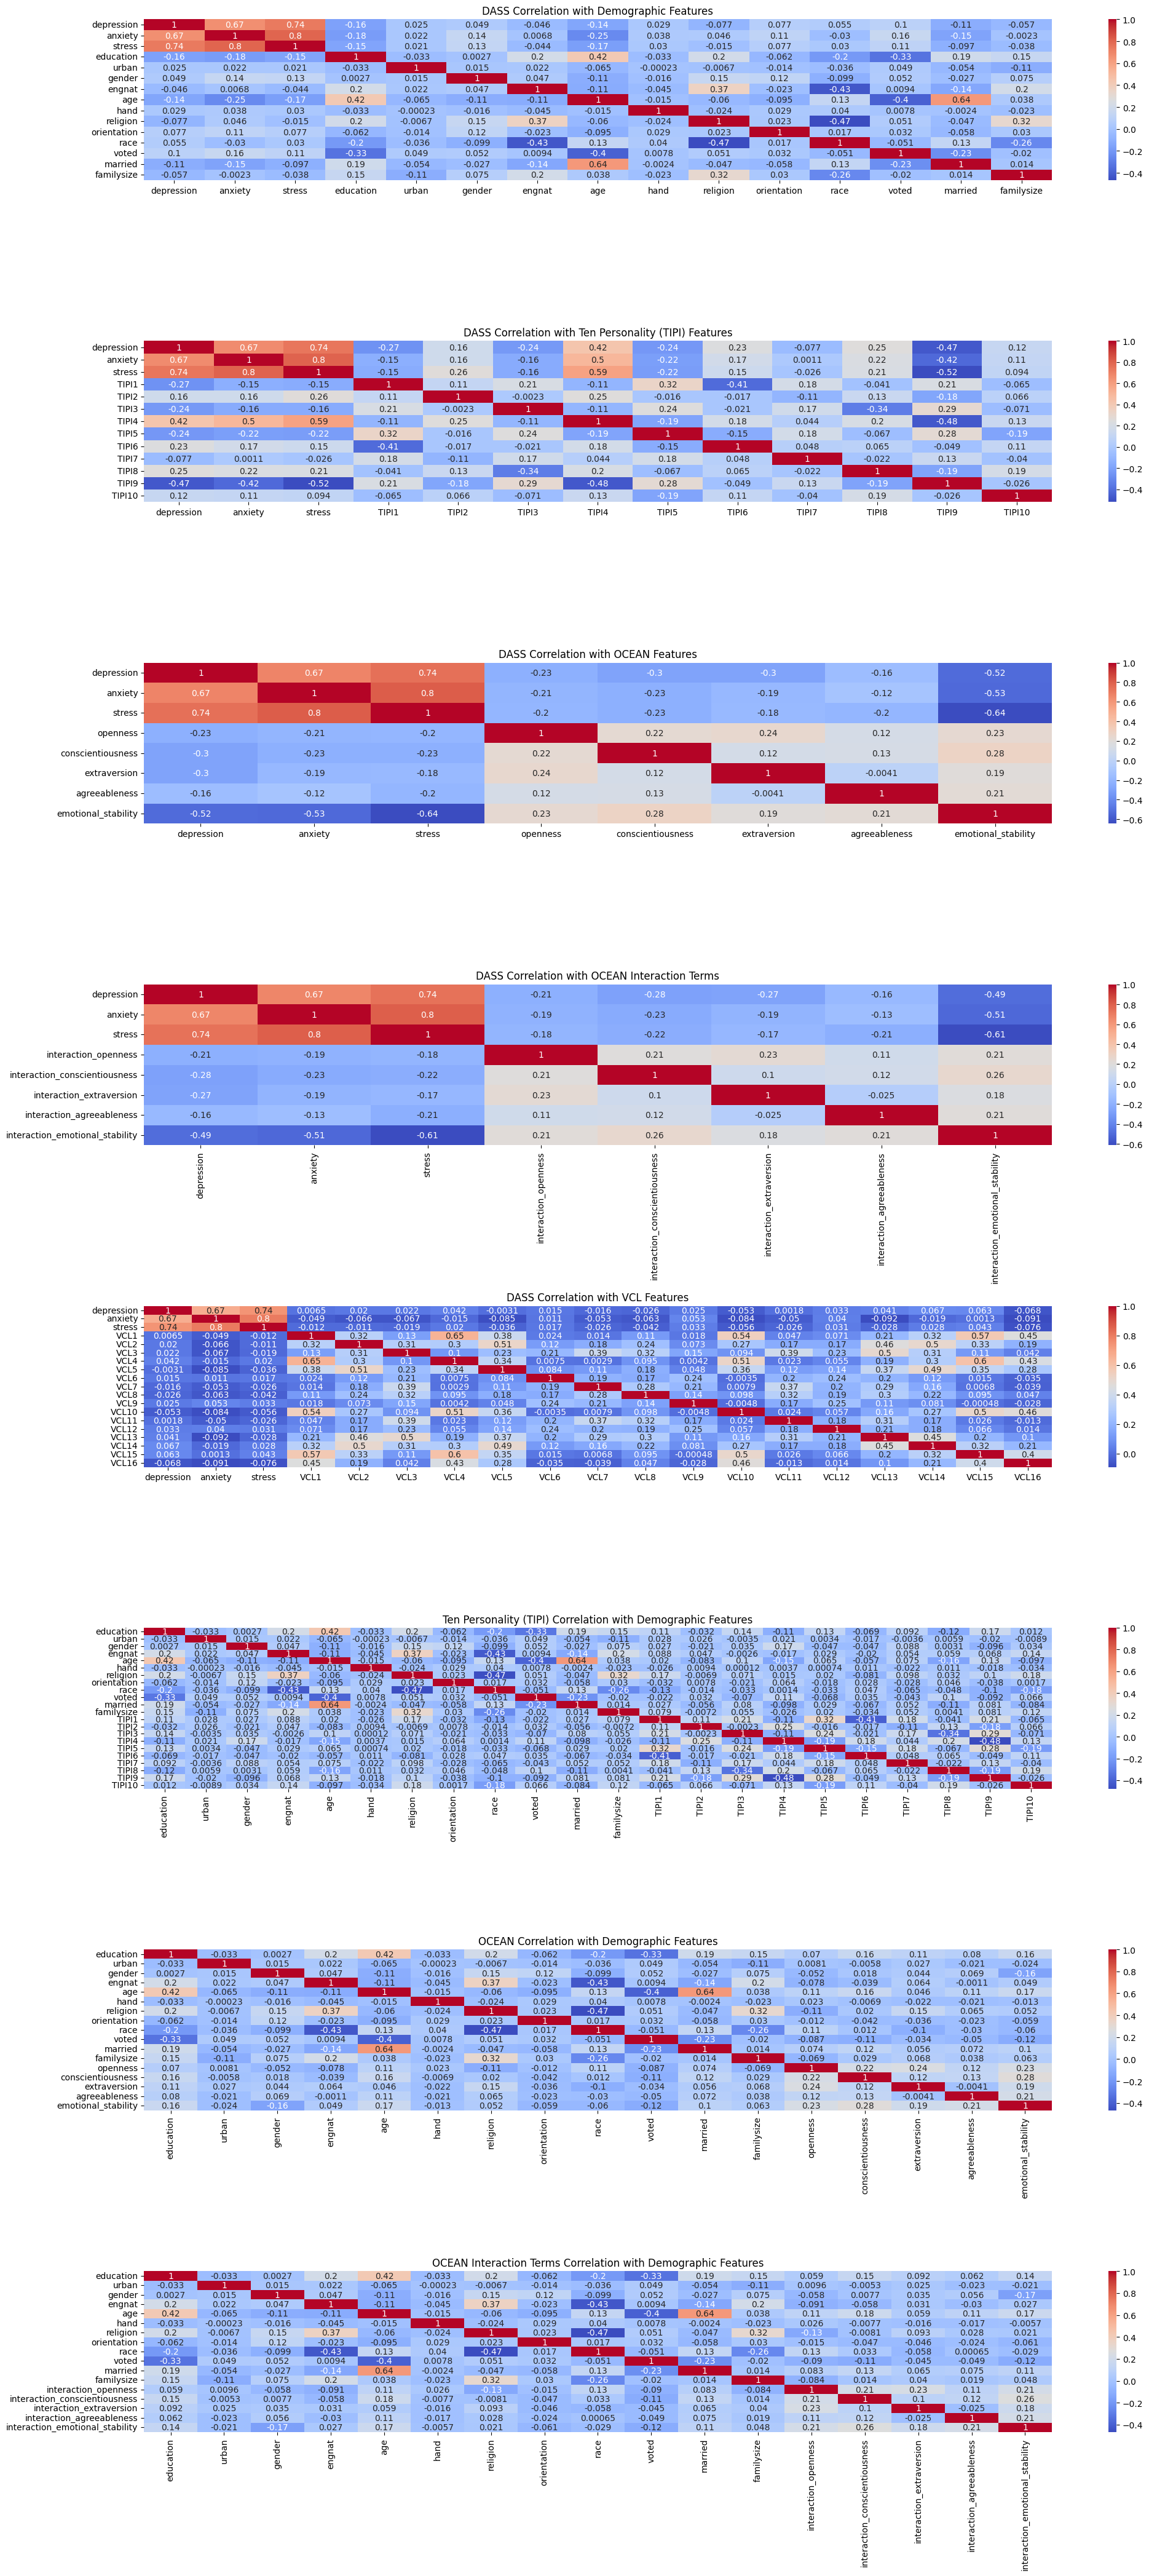

In [36]:
fig, axes = plt.subplots(8, figsize=(21, 42))

sns.heatmap(corr_matrix_demo, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('DASS Correlation with Demographic Features')

sns.heatmap(corr_matrix_tipi, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('DASS Correlation with Ten Personality (TIPI) Features')

sns.heatmap(corr_matrix_ocean, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('DASS Correlation with OCEAN Features')

sns.heatmap(corr_matrix_ocean_interaction, annot=True, cmap='coolwarm', ax=axes[3])
axes[3].set_title('DASS Correlation with OCEAN Interaction Terms')

sns.heatmap(corr_matrix_vcl, annot=True, cmap='coolwarm', ax=axes[4])
axes[4].set_title('DASS Correlation with VCL Features')

sns.heatmap(corr_matrix_demo_tipi, annot=True, cmap='coolwarm', ax=axes[5])
axes[5].set_title('Ten Personality (TIPI) Correlation with Demographic Features')

sns.heatmap(df[demo_headers + ocean_headers].corr(), annot=True, cmap='coolwarm', ax=axes[6])
axes[6].set_title('OCEAN Correlation with Demographic Features')

sns.heatmap(df[demo_headers + ocean_interaction_terms].corr(), annot=True, cmap='coolwarm', ax=axes[7])
axes[7].set_title('OCEAN Interaction Terms Correlation with Demographic Features')

plt.tight_layout()
plt.show()

In [18]:
print(tipi_dict)

{'TIPI1': 'Extraverted, enthusiastic', 'TIPI2': 'Critical, quarrelsome', 'TIPI3': 'Dependable, self-disciplined', 'TIPI4': 'Anxious, easily upset', 'TIPI5': 'Open to new experiences, complex', 'TIPI6': 'Reserved, quiet', 'TIPI7': 'Sympathetic, warm', 'TIPI8': 'Disorganized, careless.', 'TIPI9': 'Calm, emotionally stable.', 'TIPI10': 'Conventional, uncreative.'}


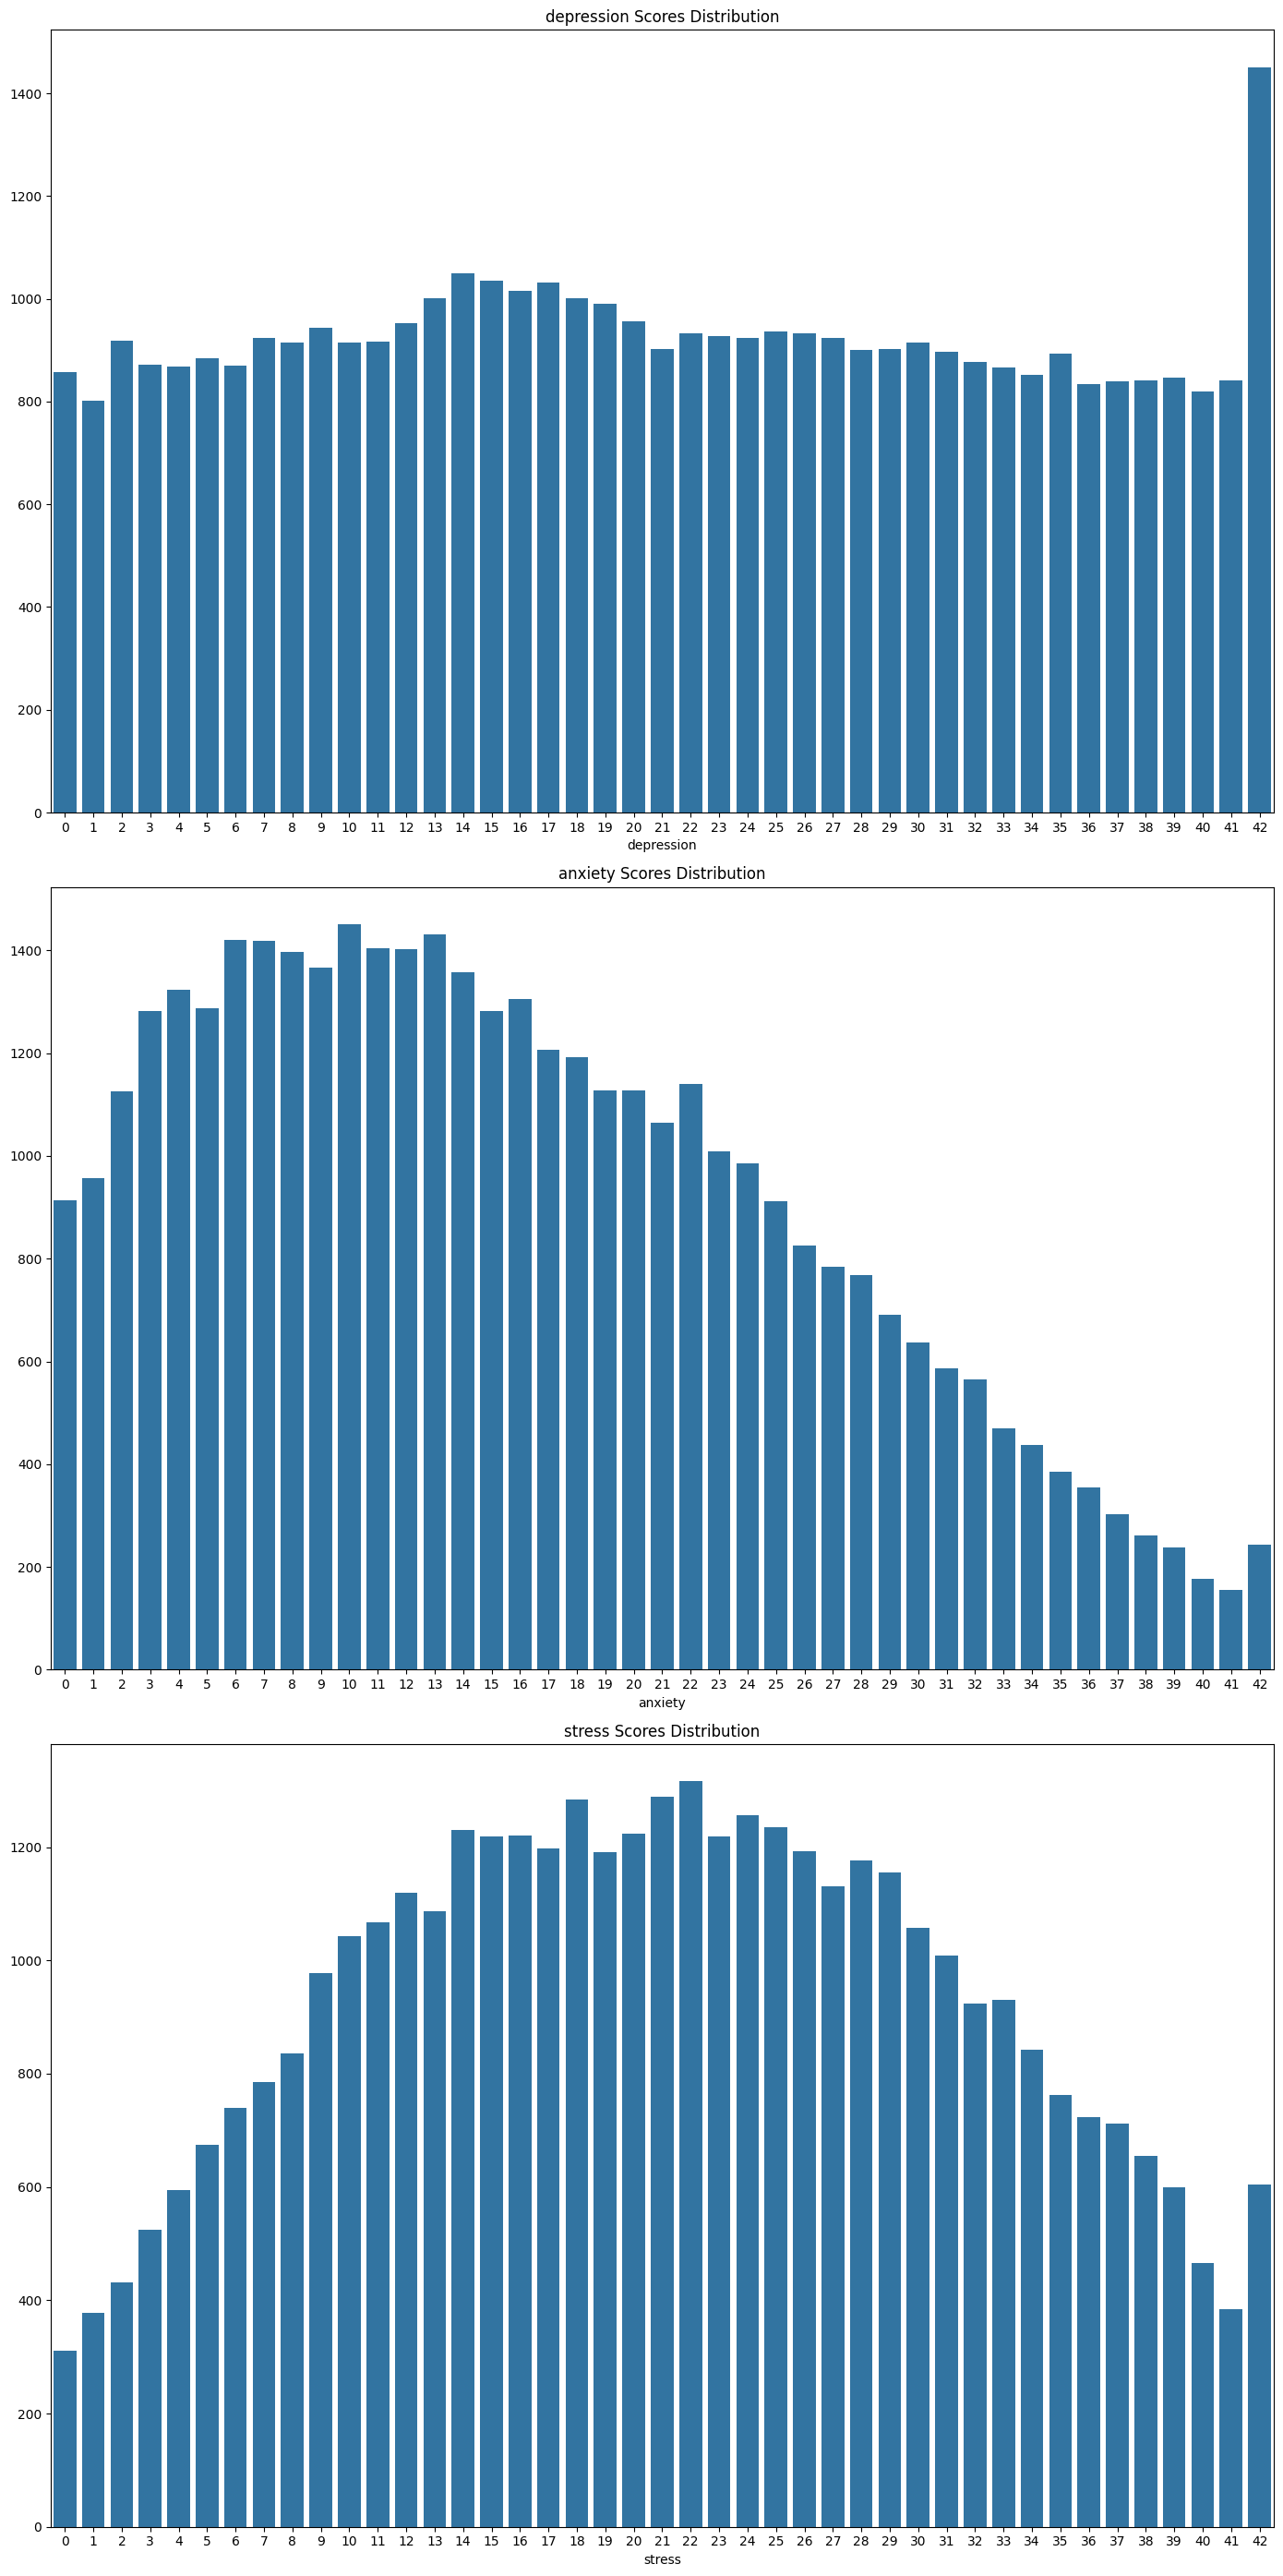

In [19]:
# DASS Classification Visualization
headers = ['depression', 'anxiety', 'stress']

fig, ax = plt.subplots(3, figsize=(14, 28))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(headers):
    header_counts = df[values].value_counts()
    sns.barplot(x = header_counts.index, y = header_counts.values, ax=ax[i])
    ax[i].set_title(f'{values} Scores Distribution')

fig.tight_layout()
plt.show()

In [20]:
# DASS Headers from Questions
depression_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
anxiety_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A', 'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

headers = depression_items + anxiety_items + stress_items

unique_values_dict = {}

# Loop header
for header in headers:
    if header in df.columns:
        unique_values = df[header].unique()
        unique_values_dict[header] = unique_values

# print unique values
for header, values in unique_values_dict.items():
    print(f"{header}: {values}")

Q3A: [1 3 2 0]
Q5A: [3 2 0 1]
Q10A: [0 1 3 2]
Q13A: [3 0 1 2]
Q16A: [3 2 1 0]
Q17A: [2 3 1 0]
Q21A: [0 1 3 2]
Q24A: [3 1 0 2]
Q26A: [3 2 0 1]
Q31A: [3 1 2 0]
Q34A: [2 1 3 0]
Q37A: [0 3 1 2]
Q38A: [1 3 0 2]
Q42A: [3 1 2 0]
Q2A: [3 0 2 1]
Q4A: [3 2 0 1]
Q7A: [3 2 0 1]
Q9A: [1 2 3 0]
Q15A: [3 2 1 0]
Q19A: [2 0 1 3]
Q20A: [2 0 1 3]
Q23A: [3 0 1 2]
Q25A: [3 1 0 2]
Q28A: [2 3 0 1]
Q30A: [1 2 3 0]
Q36A: [3 2 0 1]
Q40A: [2 0 1 3]
Q41A: [3 1 0 2]
Q1A: [3 2 1 0]
Q6A: [3 2 1 0]
Q8A: [3 2 1 0]
Q11A: [3 1 0 2]
Q12A: [3 1 0 2]
Q14A: [3 0 2 1]
Q18A: [3 1 0 2]
Q22A: [3 2 0 1]
Q27A: [3 2 1 0]
Q29A: [3 2 1 0]
Q32A: [3 2 0 1]
Q33A: [1 2 0 3]
Q35A: [3 1 2 0]
Q39A: [3 1 2 0]


Note:
- Depression, anxiety, and stress score distribution is incorrect as the values for the questionnare's answer is 1-4 instead of 0-3.

In [21]:
df[['depression', 'anxiety', 'stress']].describe()

,depression,anxiety,stress
count,39775.000000,39775.000000,39775.000000
mean,21.060088,16.054758,21.153891
std,12.321566,10.249169,10.523291
min,0.000000,0.000000,0.000000
25%,11.000000,8.000000,13.000000
50%,21.000000,15.000000,21.000000
75%,32.000000,23.000000,29.000000
max,42.000000,42.000000,42.000000


In [22]:
df[['depression_class', 'anxiety_class', 'stress_class']].describe()

,depression_class,anxiety_class,stress_class
count,39775.000000,39775.000000,39775.000000
mean,2.305041,2.305141,1.787605
std,1.555965,1.590165,1.434948
min,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000
50%,3.000000,3.000000,2.000000
75%,4.000000,4.000000,3.000000
max,4.000000,4.000000,4.000000


In [23]:
# Show depression, anxiety, and stress class distribution
depression_class_counts = df['depression_class'].value_counts().sort_index()
anxiety_class_counts = df['anxiety_class'].value_counts().sort_index()
stress_class_counts = df['stress_class'].value_counts().sort_index()

depression_class_counts, anxiety_class_counts, stress_class_counts

(depression_class
 0     8856
 1     3786
 2     7079
 3     6477
 4    13577
 Name: count, dtype: int64,
 anxiety_class
 0     9728
 1     2764
 2     7048
 3     6113
 4    14122
 Name: count, dtype: int64,
 stress_class
 0    11800
 1     4921
 2     8730
 3     8575
 4     5749
 Name: count, dtype: int64)